# 01 — Almgren-Chriss Model Intuition

This notebook explores the **risk/cost efficient frontier** and the impact of each parameter on the optimal trajectory.

Key formula: $x^*(t) = X \cdot \frac{\sinh(\kappa(T-t))}{\sinh(\kappa T)}$, with $\kappa = \sqrt{\lambda \sigma^2 / \eta}$

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from src.almgren_chriss import AlmgrenChrissModel

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('✓ Imports OK')

✓ Imports OK


## 1. Optimal trajectories for different λ values

- **λ=0** → TWAP (uniform liquidation, maximises risk)
- **λ→∞** → immediate liquidation (minimises risk, maximises cost)

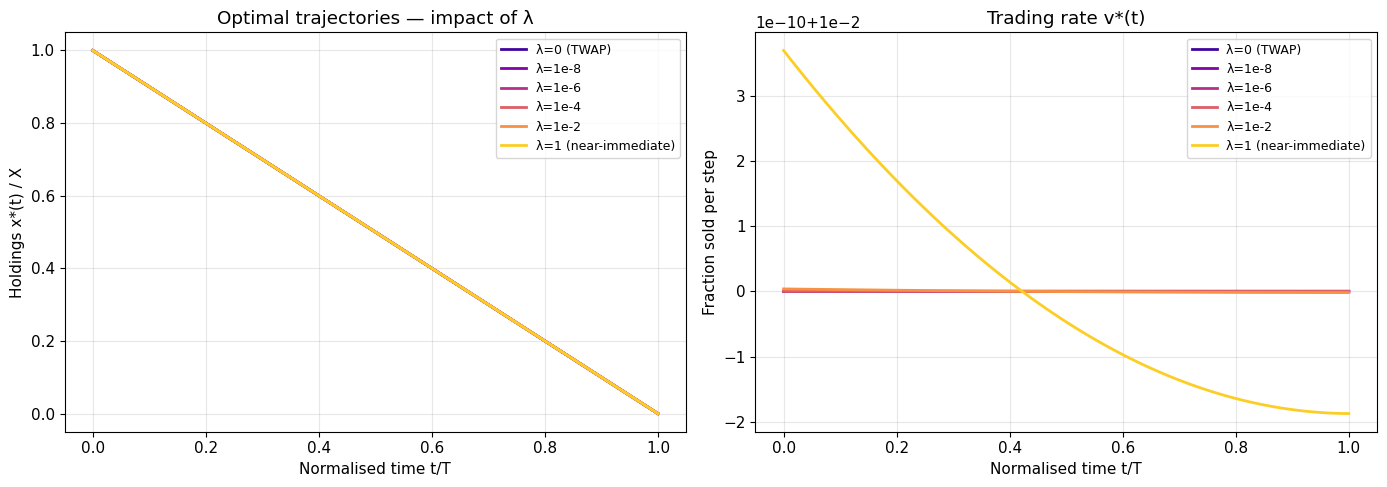


κ for each λ:
  λ=0 (TWAP)                     κ = 0.000000
  λ=1e-8                         κ = 0.000008
  λ=1e-6                         κ = 0.000085
  λ=1e-4                         κ = 0.000845
  λ=1e-2                         κ = 0.008452
  λ=1 (near-immediate)           κ = 0.084515


In [3]:
BASE = dict(X=100_000, T=1/252, N=100, sigma=0.30/np.sqrt(252), eta=0.05, gamma=0.01)

lambdas = [0.0, 1e-8, 1e-6, 1e-4, 1e-2, 1.0]
labels  = ['λ=0 (TWAP)', 'λ=1e-8', 'λ=1e-6', 'λ=1e-4', 'λ=1e-2', 'λ=1 (near-immediate)']
colors  = cm.plasma(np.linspace(0.1, 0.9, len(lambdas)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for lam, label, color in zip(lambdas, labels, colors):
    m = AlmgrenChrissModel(**BASE, lam=lam)
    traj = m.optimal_trajectory()
    t = np.linspace(0, 1, len(traj))  # normalize time to [0,1]
    ax1.plot(t, traj / BASE['X'], color=color, lw=2, label=label)

ax1.set_xlabel('Normalised time t/T')
ax1.set_ylabel('Holdings x*(t) / X')
ax1.set_title('Optimal trajectories — impact of λ')
ax1.legend(fontsize=9, loc='upper right')

# Trading rates
for lam, label, color in zip(lambdas, labels, colors):
    m = AlmgrenChrissModel(**BASE, lam=lam)
    traj = m.optimal_trajectory()
    trades = traj[:-1] - traj[1:]
    t = np.linspace(0, 1, len(trades))
    ax2.plot(t, trades / BASE['X'], color=color, lw=2, label=label)

ax2.set_xlabel('Normalised time t/T')
ax2.set_ylabel('Fraction sold per step')
ax2.set_title('Trading rate v*(t)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('\nκ for each λ:')
for lam, label in zip(lambdas, labels):
    m = AlmgrenChrissModel(**BASE, lam=lam)
    print(f'  {label:30s} κ = {m.kappa:.6f}')

## 2. Cost-Risk Efficient Frontier

Analogue of the Markowitz frontier, but in the (√Var[C], E[C]) space.

- Each point corresponds to a different λ
- TWAP = maximum risk, minimum cost point
- Immediate liquidation = zero risk, maximum cost

In [ ]:
model = AlmgrenChrissModel(**BASE, lam=1e-6)
risks, costs = model.efficient_frontier(n_points=300)

# Reference strategy positions
e_twap, v_twap = model.cost_from_trajectory(model.twap_trajectory())
e_vwap, v_vwap = model.cost_from_trajectory(model.vwap_trajectory())

# Selected λ positions
pts = {}
for lam in [1e-8, 1e-6, 1e-4, 1e-2]:
    model.lam = lam
    e, v = model._closed_form_cost_variance()
    pts[lam] = (np.sqrt(v), e)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(risks, costs, 'b-', lw=2.5, label='Almgren-Chriss efficient frontier')

# Reference strategies
ax.scatter([np.sqrt(v_twap)], [e_twap], s=200, c='green',  marker='s', zorder=6, label='TWAP')
ax.scatter([np.sqrt(v_vwap)], [e_vwap], s=200, c='orange', marker='^', zorder=6, label='VWAP')

# Lambda points
for lam, (r, c) in pts.items():
    ax.scatter(r, c, s=120, zorder=6, label=f'λ={lam:.0e}')

ax.set_xlabel('Risk  $\\sqrt{Var[C]}$', fontsize=13)
ax.set_ylabel('Expected cost  $E[C]$', fontsize=13)
ax.set_title('Almgren-Chriss Efficient Frontier', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 3. Parametric Sensitivity

How do σ, η, γ shift the frontier and the optimal trajectory?

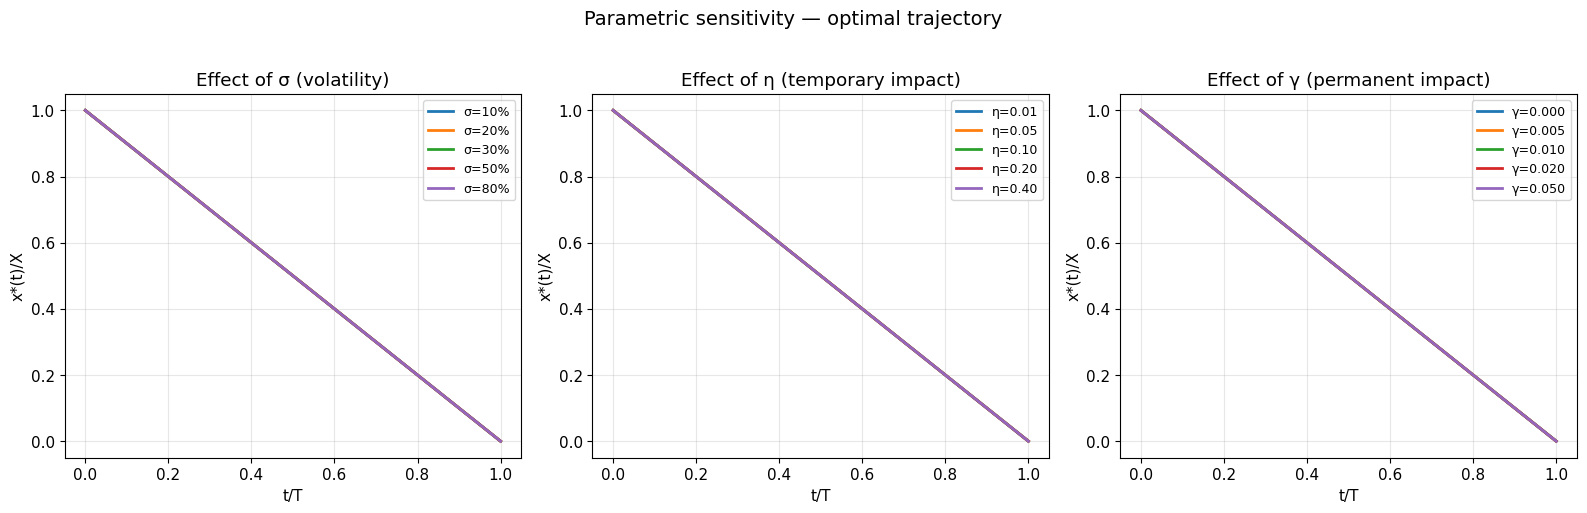

Note: γ (permanent impact) does not change the shape of the trajectory
because it contributes a fixed cost (γ/2)X² independent of the path.
However σ and η directly control κ = √(λσ²/η).


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

LAM = 1e-5

# ── σ sensitivity ────────────────────────────────────────────────────────────
ax = axes[0]
for sigma_ann in [0.10, 0.20, 0.30, 0.50, 0.80]:
    m = AlmgrenChrissModel(**{**BASE, 'sigma': sigma_ann/np.sqrt(252), 'lam': LAM})
    t = np.linspace(0, 1, m.N + 1)
    ax.plot(t, m.optimal_trajectory() / BASE['X'], lw=2, label=f'σ={sigma_ann:.0%}')
ax.set_title('Effect of σ (volatility)')
ax.set_xlabel('t/T'); ax.set_ylabel('x*(t)/X')
ax.legend(fontsize=9)

# ── η sensitivity ────────────────────────────────────────────────────────────
ax = axes[1]
for eta_val in [0.01, 0.05, 0.10, 0.20, 0.40]:
    m = AlmgrenChrissModel(**{**BASE, 'eta': eta_val, 'lam': LAM})
    t = np.linspace(0, 1, m.N + 1)
    ax.plot(t, m.optimal_trajectory() / BASE['X'], lw=2, label=f'η={eta_val:.2f}')
ax.set_title('Effect of η (temporary impact)')
ax.set_xlabel('t/T'); ax.set_ylabel('x*(t)/X')
ax.legend(fontsize=9)

# ── γ sensitivity ────────────────────────────────────────────────────────────
ax = axes[2]
for gamma_val in [0.0, 0.005, 0.01, 0.02, 0.05]:
    m = AlmgrenChrissModel(**{**BASE, 'gamma': gamma_val, 'lam': LAM})
    t = np.linspace(0, 1, m.N + 1)
    ax.plot(t, m.optimal_trajectory() / BASE['X'], lw=2, label=f'γ={gamma_val:.3f}')
ax.set_title('Effect of γ (permanent impact)')
ax.set_xlabel('t/T'); ax.set_ylabel('x*(t)/X')
ax.legend(fontsize=9)

plt.suptitle('Parametric sensitivity — optimal trajectory', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Note: γ (permanent impact) does not change the shape of the trajectory')
print('because it contributes a fixed cost (γ/2)X² independent of the path.')
print('However σ and η directly control κ = √(λσ²/η).')

## 4. Numerical Verification

The discrete solution should converge to the continuous analytical solution as N→∞.

In [ ]:
Ns = [5, 10, 20, 50, 100, 200, 500]
errors_cost = []
errors_var  = []

for N_val in Ns:
    m = AlmgrenChrissModel(**{**BASE, 'N': N_val, 'lam': 1e-5})
    e_an, v_an = m._closed_form_cost_variance()
    e_disc, v_disc = m.cost_from_trajectory(m.optimal_trajectory())
    errors_cost.append(abs(e_an - e_disc) / e_an * 100)
    errors_var.append(abs(v_an - v_disc) / v_an * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(Ns, errors_cost, 'b-o', label='Error E[C] (%)')
ax.loglog(Ns, errors_var,  'r-s', label='Error Var[C] (%)')
ax.set_xlabel('N (number of steps)')
ax.set_ylabel('Relative error (%)')
ax.set_title('Convergence: discrete → continuous')
ax.legend()
plt.tight_layout()
plt.show()

print('Relative errors: analytical vs discrete:')
for N_val, ec, ev in zip(Ns, errors_cost, errors_var):
    print(f'  N={N_val:4d} | E[C]: {ec:.4f}%  | Var[C]: {ev:.4f}%')